# Подготовка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузим исходный датасет и заново выполним обработку пропусков, чтобы дальше работать уже с подготовленными данными из 4-го задания
df = pd.read_csv("loan_prediction_dataset.csv")

df_filled = df.copy()

for col in ["Gender", "Married", "Dependents", "Self_Employed"]:
    df_filled[col] = df_filled[col].fillna(df_filled[col].mode()[0])

for col in ["LoanAmount", "Loan_Amount_Term"]:
    df_filled[col] = df_filled[col].fillna(df_filled[col].median())

df_filled["Credit_History"] = df_filled["Credit_History"].fillna(
    df_filled["Credit_History"].mode()[0]
)

df_filled.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# Задание 1. Найдите выбросы для ApplicantIncome и LoanAmount двумя способами

## Определим методы для двух способов

In [ ]:
def find_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return outliers, lower_bound, upper_bound

def find_outliers_std(series):
    mean = series.mean()
    std = series.std()

    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return outliers, lower_bound, upper_bound

## **IQR-правило**

In [ ]:
app_income_iqr_outliers, app_income_iqr_lower, app_income_iqr_upper = find_outliers_iqr(
    df_filled["ApplicantIncome"]
)

print("Нижняя граница для ApplicantIncome:", round(app_income_iqr_lower, 2))
print("Верхняя граница для ApplicantIncome:", round(app_income_iqr_upper, 2))
print("Количество выбросов:", len(app_income_iqr_outliers))

app_income_iqr_outliers.head()

Нижняя граница для ApplicantIncome: -1498.75
Верхняя граница для ApplicantIncome: 10171.25
Количество выбросов: 50


,ApplicantIncome
9,12841
34,12500
54,11500
67,10750
102,13650


In [ ]:
loan_amount_iqr_outliers, loan_amount_iqr_lower, loan_amount_iqr_upper = find_outliers_iqr(
    df_filled["LoanAmount"]
)

print("Нижняя граница для LoanAmount:", round(loan_amount_iqr_lower, 2))
print("Верхняя граница для LoanAmount:", round(loan_amount_iqr_upper, 2))
print("Количество выбросов:", len(loan_amount_iqr_outliers))

loan_amount_iqr_outliers.head()

Нижняя граница для LoanAmount: 3.5
Верхняя граница для LoanAmount: 261.5
Количество выбросов: 41


,LoanAmount
5,267.0
9,349.0
21,315.0
34,320.0
54,286.0


## **Метод стандартного отклонения (std)**

In [ ]:
app_income_std_outliers, app_income_std_lower, app_income_std_upper = find_outliers_std(
    df_filled["ApplicantIncome"]
)

print("Нижняя граница для ApplicantIncome:", round(app_income_std_lower, 2))
print("Верхняя граница для ApplicantIncome:", round(app_income_std_upper, 2))
print("Количество выбросов:", len(app_income_std_outliers))

app_income_std_outliers.head()

Нижняя граница для ApplicantIncome: -12923.67
Верхняя граница для ApplicantIncome: 23730.58
Количество выбросов: 8


,ApplicantIncome
126,23803
155,39999
171,51763
183,33846
185,39147


In [ ]:
loan_amount_std_outliers, loan_amount_std_lower, loan_amount_std_upper = find_outliers_std(
    df_filled["LoanAmount"]
)

print("Нижняя граница для LoanAmount:", round(loan_amount_std_lower, 2))
print("Верхняя граница для LoanAmount:", round(loan_amount_std_upper, 2))
print("Количество выбросов:", len(loan_amount_std_outliers))

loan_amount_std_outliers.head()

Нижняя граница для LoanAmount: -106.57
Верхняя граница для LoanAmount: 398.07
Количество выбросов: 15


,LoanAmount
130,650.0
155,600.0
171,700.0
177,495.0
278,436.0


# Задание 2. Сравните пересечение и расхождения списков наблюдений; кратко объясните причины различий

In [ ]:
app_iqr_idx = set(app_income_iqr_outliers.index)
app_std_idx = set(app_income_std_outliers.index)

loan_iqr_idx = set(loan_amount_iqr_outliers.index)
loan_std_idx = set(loan_amount_std_outliers.index)

## Посмотрим пересечение и различия для `ApplicantIncome`.

In [ ]:
app_intersection = app_iqr_idx & app_std_idx
app_only_iqr = app_iqr_idx - app_std_idx
app_only_std = app_std_idx - app_iqr_idx

print("ApplicantIncome")
print("Общие выбросы:", len(app_intersection))
print("Только IQR:", len(app_only_iqr))
print("Только std:", len(app_only_std))

ApplicantIncome
Общие выбросы: 8
Только IQR: 42
Только std: 0


## Теперь сравним результаты для `LoanAmount`.

In [ ]:
loan_intersection = loan_iqr_idx & loan_std_idx
loan_only_iqr = loan_iqr_idx - loan_std_idx
loan_only_std = loan_std_idx - loan_iqr_idx

print("LoanAmount")
print("Общие выбросы:", len(loan_intersection))
print("Только IQR:", len(loan_only_iqr))
print("Только std:", len(loan_only_std))

LoanAmount
Общие выбросы: 15
Только IQR: 26
Только std: 0


### Краткий комментарий

Методы IQR и стандартного отклонения могут давать разные результаты, потому что они основаны на разных принципах.

- **IQR-правило** опирается на квартили и межквартильный размах, поэтому оно лучше работает при асимметричном распределении и меньше зависит от крайних значений.
- **Метод стандартного отклонения** использует среднее значение и разброс относительно него, поэтому сильнее зависит от формы распределения и самих экстремальных наблюдений.

Если распределение признака далеко от нормального, расхождения между этими двумя методами становятся особенно заметными.

# Задание 3. Визуально подтвердите наличие выбросов (boxplot / гистограммы)

На boxplot для `ApplicantIncome` можно увидеть значения, которые сильно выходят за пределы основного диапазона.  
Гистограмма также показывает правостороннюю асимметрию распределения и наличие очень больших значений.

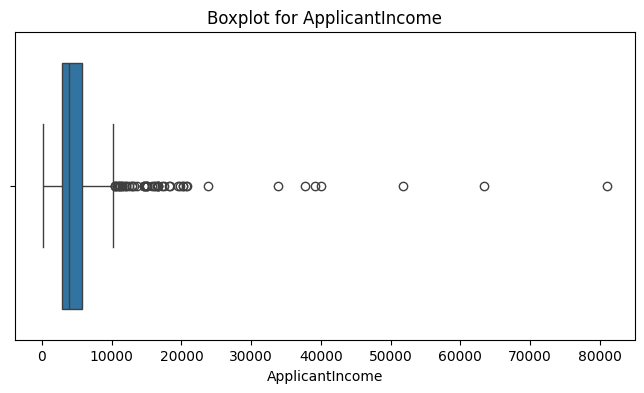

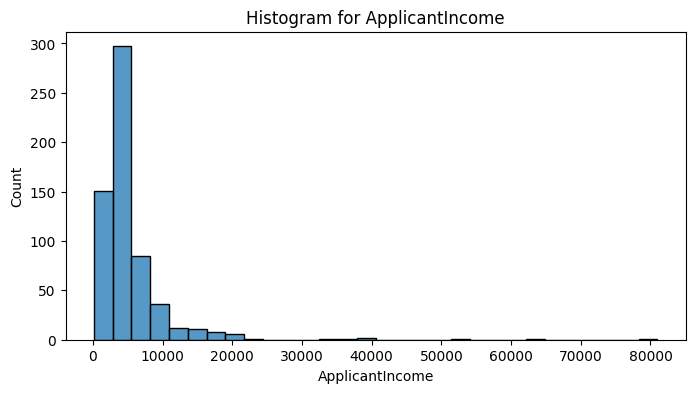

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_filled["ApplicantIncome"])
plt.title("Boxplot for ApplicantIncome")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_filled["ApplicantIncome"], bins=30)
plt.title("Histogram for ApplicantIncome")
plt.xlabel("ApplicantIncome")
plt.ylabel("Count")
plt.show()

Для признака `LoanAmount` также заметны значения, которые расположены далеко от основной массы наблюдений.  
По графикам видно, что распределение не является идеально симметричным, поэтому оба метода могут находить выбросы немного по-разному.

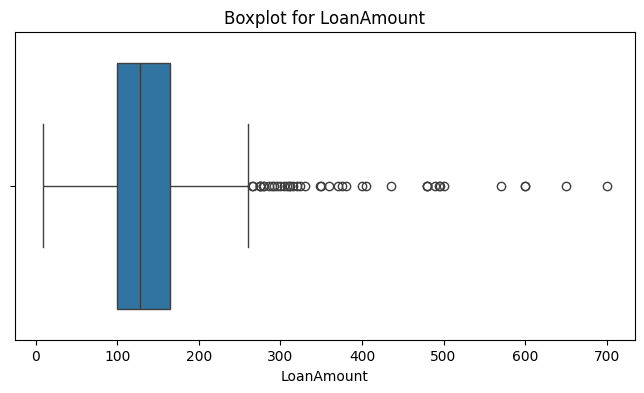

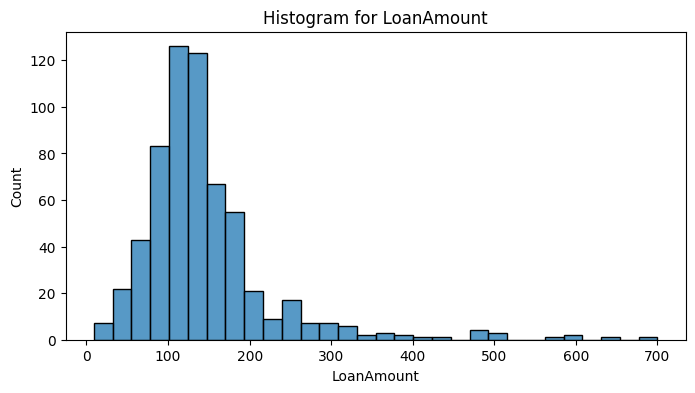

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_filled["LoanAmount"])
plt.title("Boxplot for LoanAmount")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_filled["LoanAmount"], bins=30)
plt.title("Histogram for LoanAmount")
plt.xlabel("LoanAmount")
plt.ylabel("Count")
plt.show()

# Задание 4. Решение по обработке выбросов

Примите решение:

- удалить выбросы,
- заменить,
- оставить
Обоснуйте выбор

В данном случае выбросы не будем удалять полностью, а заменим их граничными значениями по правилу IQR (**capping**).  

### Почему выбран именно этот вариант:
- удаление выбросов может привести к потере полезной информации;
- очень большие значения дохода или кредита могут быть реальными, а не ошибочными;
- замена на границы позволяет уменьшить влияние экстремальных наблюдений, но сохранить все строки датасета.

In [ ]:
df_capped = df_filled.copy()

Сначала ограничим значения в `ApplicantIncome` по границам, найденным методом IQR.

In [ ]:
df_capped["ApplicantIncome"] = df_capped["ApplicantIncome"].clip(
    lower=app_income_iqr_lower,
    upper=app_income_iqr_upper
)

Теперь таким же образом обработаем `LoanAmount`.

In [ ]:
df_capped["LoanAmount"] = df_capped["LoanAmount"].clip(
    lower=loan_amount_iqr_lower,
    upper=loan_amount_iqr_upper
)

Проверим результат визуально после ограничения выбросов.

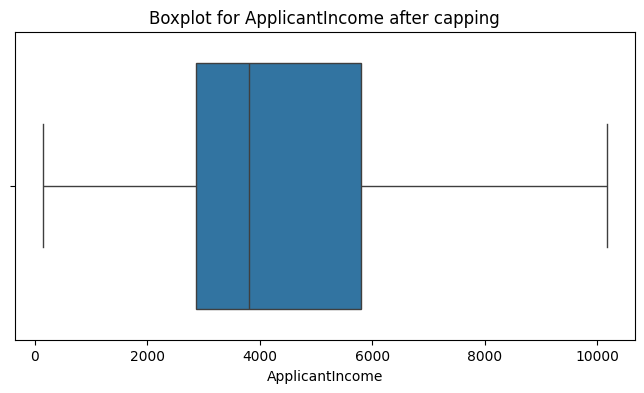

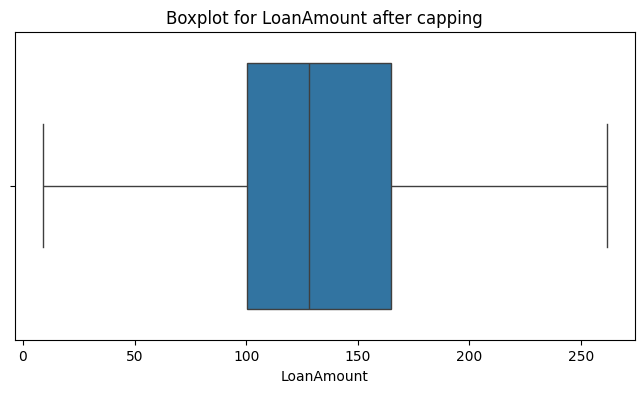

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_capped["ApplicantIncome"])
plt.title("Boxplot for ApplicantIncome after capping")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_capped["LoanAmount"])
plt.title("Boxplot for LoanAmount after capping")
plt.show()

После ограничения крайние значения стали менее выраженными, а размер датасета остался прежним.  
Это значит, что мы уменьшили влияние выбросов, не удаляя наблюдения полностью.

# Задание 5. Предложите варианты кодирования категориальных переменных, обоснуйте выбор

Для бинарных признаков `Gender`, `Married`, `Education`, `Self_Employed` и `Loan_Status` удобно использовать замену значений на `0` и `1`, потому что у них только две категории. Такой способ простой и делает данные удобными для дальнейшей обработки.

Признак `Dependents` можно перевести в числовой вид, так как он отражает количество иждивенцев и имеет естественный порядок.

Для признака `Property_Area` лучше использовать One-Hot Encoding, потому что его категории не имеют естественного порядка, и обычная замена числами могла бы создать ложное ощущение упорядоченности.

# Задание 6. Примените выбранные правила перекодирования

In [ ]:
df_encoded = df_capped.copy()

df_encoded["Gender"] = df_encoded["Gender"].map({"Male": 1, "Female": 0})
df_encoded["Married"] = df_encoded["Married"].map({"Yes": 1, "No": 0})
df_encoded["Education"] = df_encoded["Education"].map({"Graduate": 1, "Not Graduate": 0})
df_encoded["Self_Employed"] = df_encoded["Self_Employed"].map({"Yes": 1, "No": 0})
df_encoded["Loan_Status"] = df_encoded["Loan_Status"].map({"Y": 1, "N": 0})

df_encoded["Dependents"] = df_encoded["Dependents"].replace("3+", 3)
df_encoded["Dependents"] = df_encoded["Dependents"].astype(int)

df_encoded = pd.get_dummies(df_encoded, columns=["Property_Area"], dtype=int)

df_encoded.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849.0,0.0,128.0,360.0,1.0,1,0,0,1
1,LP001003,1,1,1,1,0,4583.0,1508.0,128.0,360.0,1.0,0,1,0,0
2,LP001005,1,1,0,1,1,3000.0,0.0,66.0,360.0,1.0,1,0,0,1
3,LP001006,1,1,0,0,0,2583.0,2358.0,120.0,360.0,1.0,1,0,0,1
4,LP001008,1,0,0,1,0,6000.0,0.0,141.0,360.0,1.0,1,0,0,1


# Задание 7. Проверьте результат (типы данных, размерность, отсутствие ошибок)

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Loan_ID                  614 non-null    object 
 1   Gender                   614 non-null    int64  
 2   Married                  614 non-null    int64  
 3   Dependents               614 non-null    int64  
 4   Education                614 non-null    int64  
 5   Self_Employed            614 non-null    int64  
 6   ApplicantIncome          614 non-null    float64
 7   CoapplicantIncome        614 non-null    float64
 8   LoanAmount               614 non-null    float64
 9   Loan_Amount_Term         614 non-null    float64
 10  Credit_History           614 non-null    float64
 11  Loan_Status              614 non-null    int64  
 12  Property_Area_Rural      614 non-null    int64  
 13  Property_Area_Semiurban  614 non-null    int64  
 14  Property_Area_Urban      6

In [ ]:
print("Размер датасета после кодирования:", df_encoded.shape)
print("Количество пропусков после кодирования:", df_encoded.isnull().sum().sum())

Размер датасета после кодирования: (614, 15)
Количество пропусков после кодирования: 0
